In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [2]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann

In [3]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/8sec_0overlap/data"

train_path = os.path.join(DATA_DIR, "SBP_FTEST_train.csv")
val_path   = os.path.join(DATA_DIR, "SBP_FTEST_val.csv")
test_path  = os.path.join(DATA_DIR, "SBP_FTEST_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (263103, 16)
Val:   (33223, 16)
Test:  (33347, 16)


In [4]:
TARGET = "SBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (263103, 15)
y_train: (263103,)
X_val:   (33223, 15)
y_val:   (33223,)
X_test:  (33347, 15)
y_test:  (33347,)


In [5]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/data/SBP_FTEST_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(2928374, 17)
   vpg_skewness   vpg_iqr  apg_zero_crossing_rate  vpg_energy_iqr  \
0     -0.554263  1.824971               -0.339146       -1.118971   
1     -0.573270  1.959556               -0.186419       -1.114600   
2     -0.644623  1.743451               -0.339146       -1.170703   
3     -0.709170  2.081286                0.959027       -1.029070   
4     -0.657449  2.041000                0.500849       -1.084830   

   apg_skewness  apg_shannon_entropy  apg_energy_iqr  vpg_shannon_entropy  \
0      2.973598            -0.082530       -0.544651             0.068754   
1      2.599054            -0.491994       -0.528804             0.333610   
2      2.823279             0.290188       -0.662262             0.399707   
3      2.647086             0.425392       -0.502680             0.474845   
4      2.868377             0.172152       -0.542259             0.371499   

    ppg_iqr  vpg_energy_skewness  vpg_kurtosis  vpg_kte_iqr   apg_iqr  \
0  0.766796            -0.276019   

In [6]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [7]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [8]:
print("SBP min:", y_train.min())
print("SBP max:", y_train.max())
print("SBP mean:", y_train.mean())
print("SBP std:", y_train.std())

print("SBP > 80:", np.sum(y_train > 80))
print("SBP > 90:", np.sum(y_train > 90))
print("SBP > 100:", np.sum(y_train > 100))

SBP min: 72.39897585370947
SBP max: 199.28414010847308
SBP mean: 129.94326592181736
SBP std: 22.027568517849353
SBP > 80: 262864
SBP > 90: 259096
SBP > 100: 243857


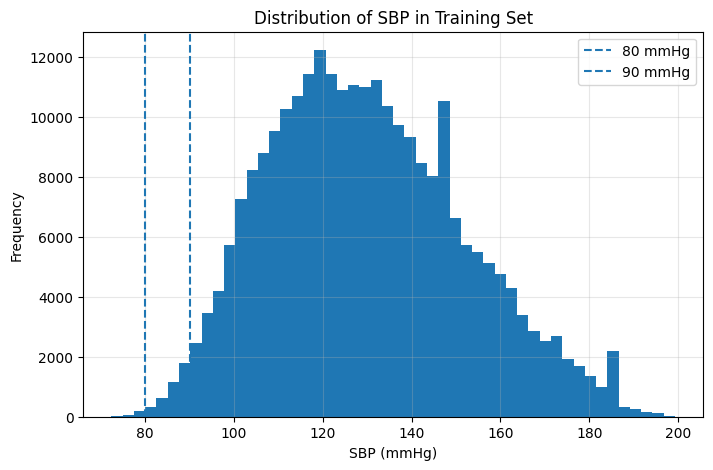

In [9]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("SBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of SBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: SBP
RMSE: 21.1305
MSE : 446.4962
R²  : 0.1546
MAE : 16.8790


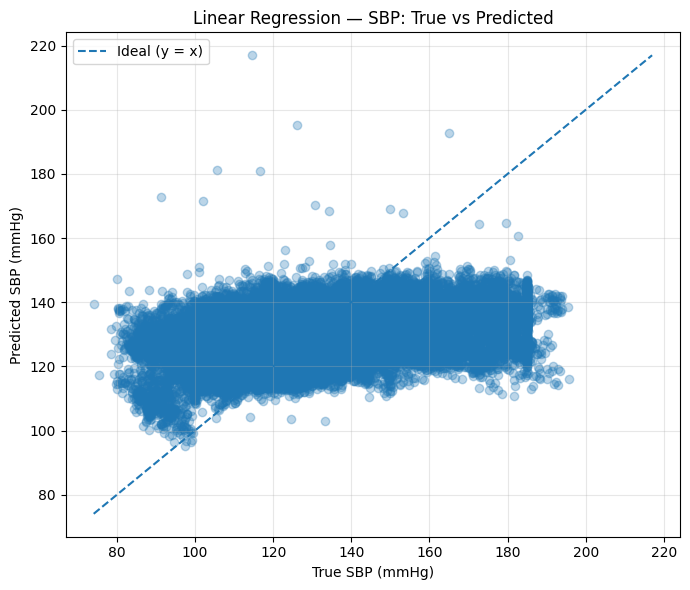

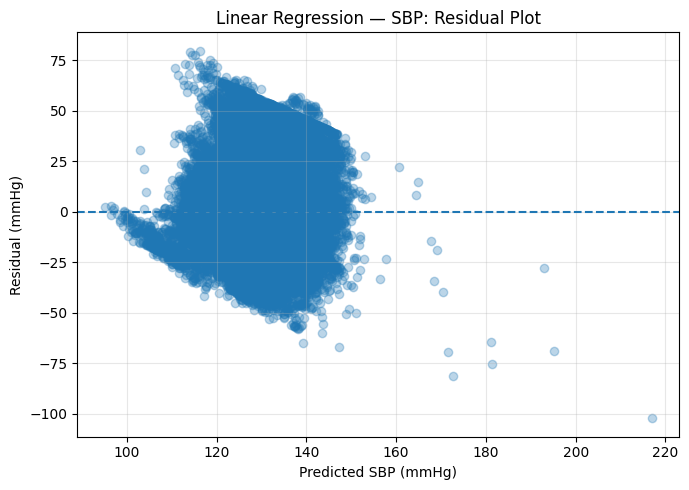

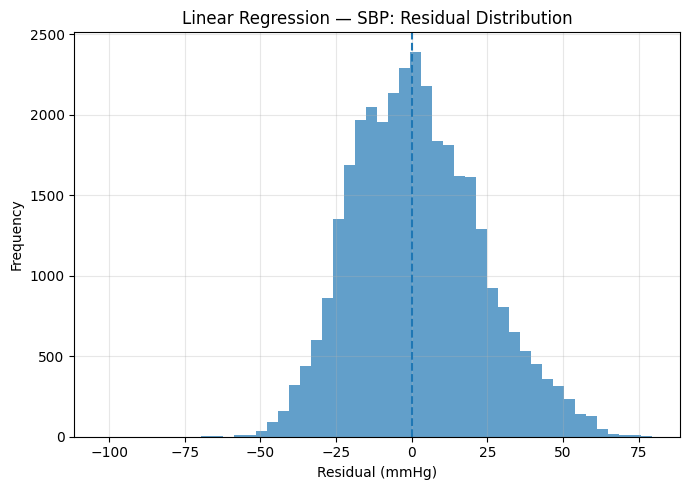

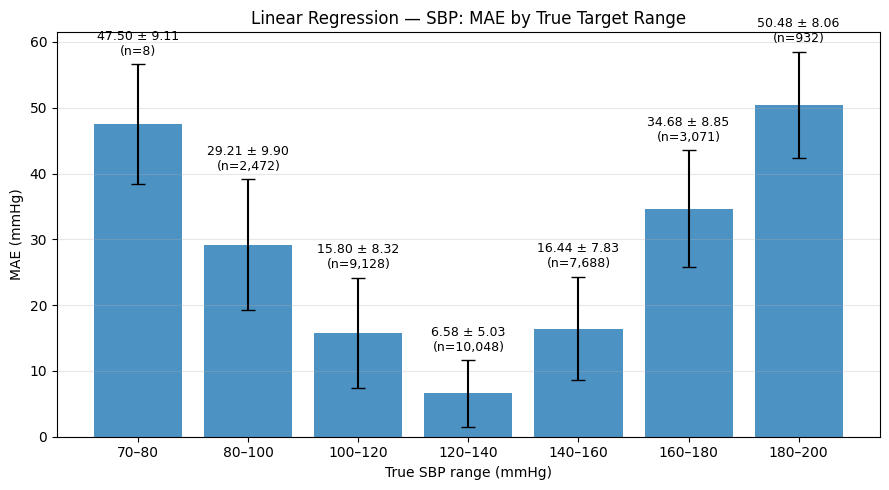

In [10]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 176.7749
MSE : 31249.3615
R²  : -72.3565
MAE : 34.9175


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


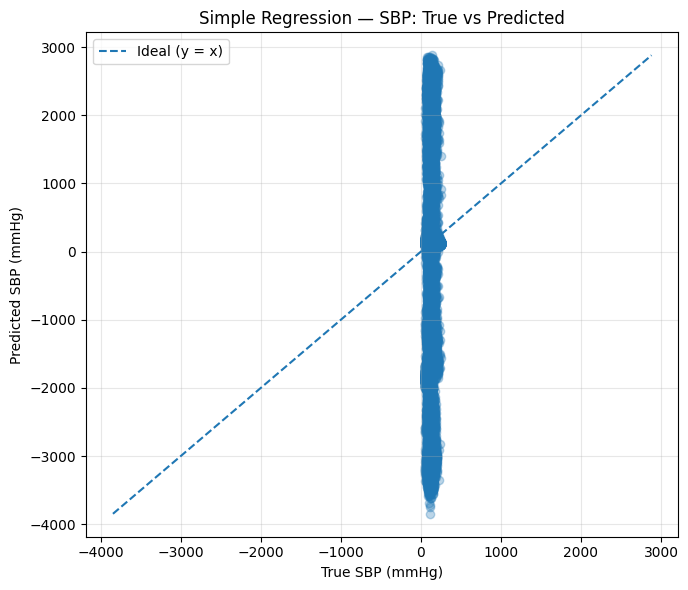

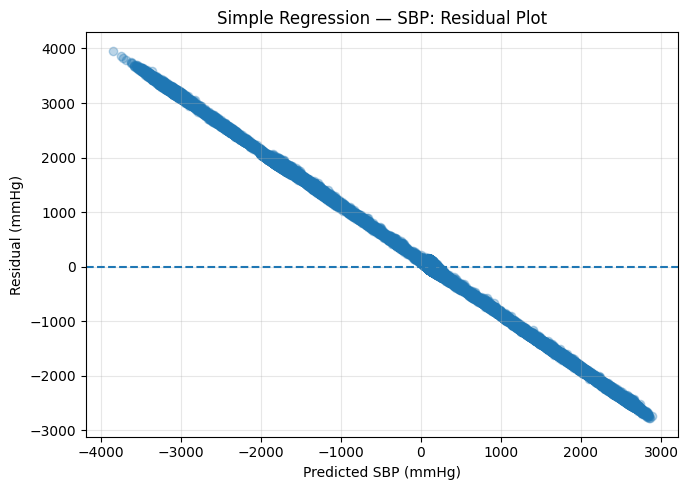

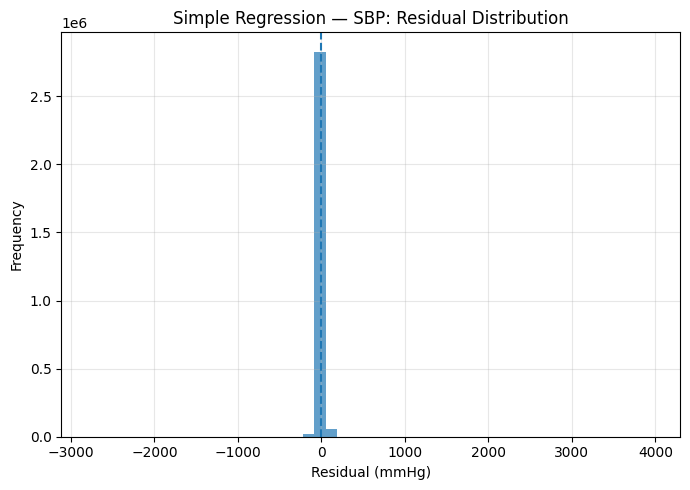

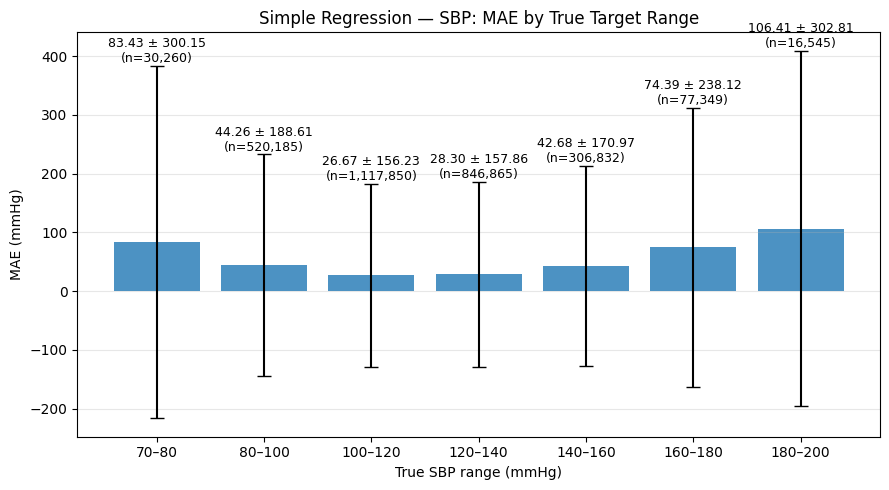

In [11]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — SBP
---------------------------------------------
RMSE: 20.3414
MSE : 413.7728
R²  : 0.2166
MAE : 16.0669


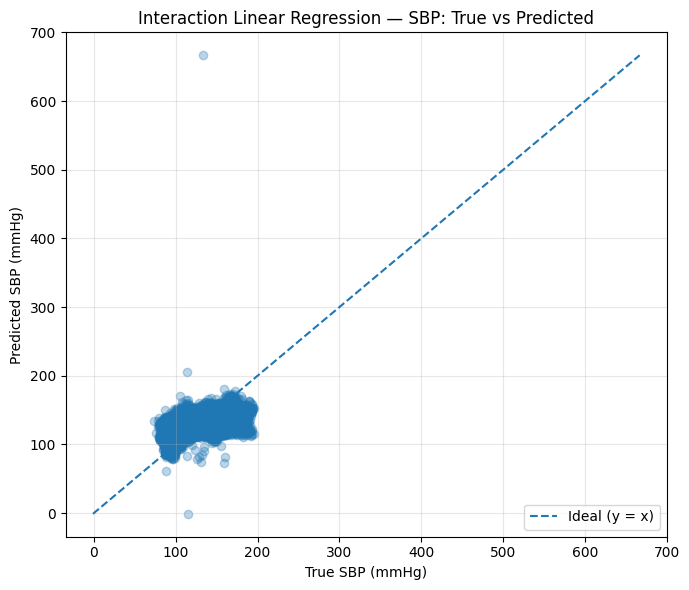

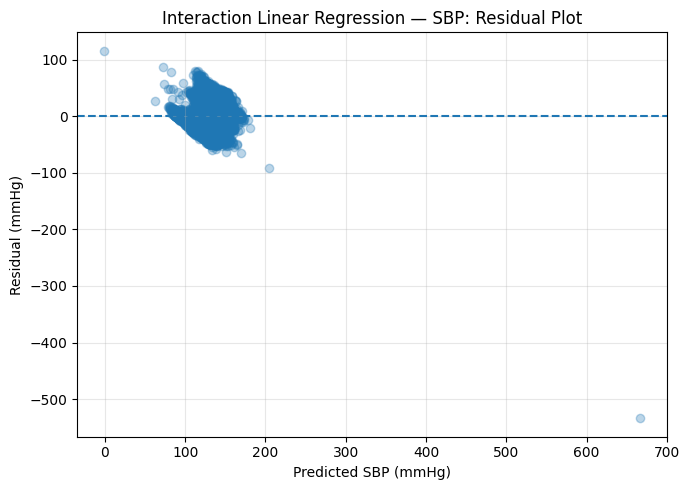

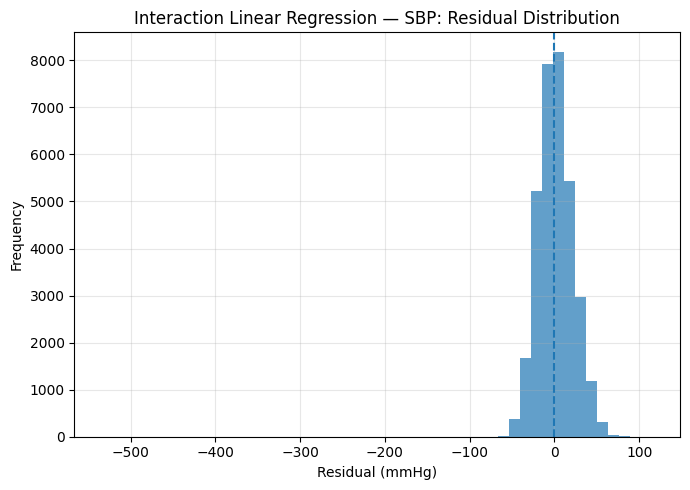

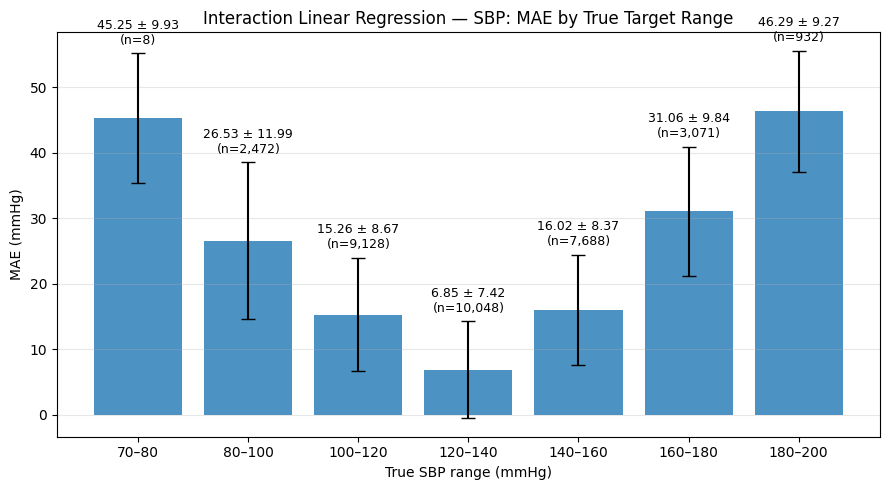

In [12]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 10213.8978
MSE : 104323708.6947
R²  : -244894.2464
MAE : 910.6430


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


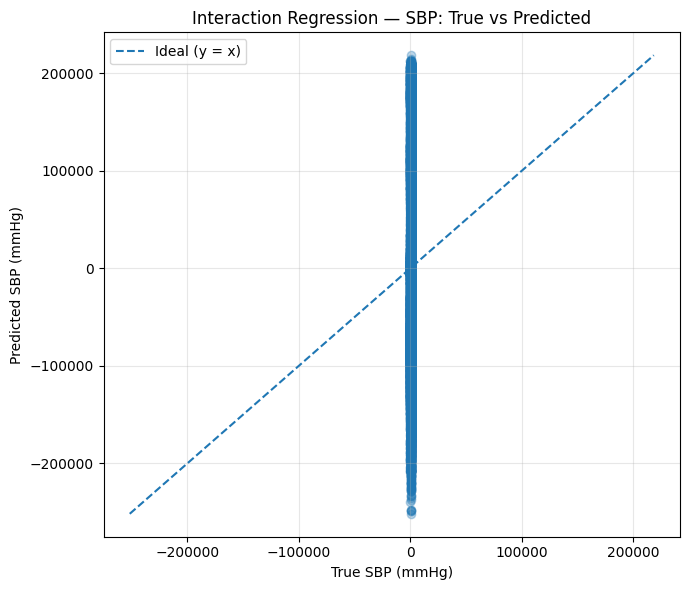

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

In [ ]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

In [ ]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

In [ ]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

In [ ]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

In [ ]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

In [ ]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

In [ ]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    gpr_model,
    "GPR_Matern",
    TARGET
)

## Rational Quadratic GPR ##

In [ ]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rq_model,
    "GPR_Rational_Quadratic",
    TARGET
)

## ANN ##

In [ ]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    ann_model,
    "ANN",
    TARGET
)